In [1]:
import pandas as pd
import numpy as np
import sklearn
import flask

print("Environment ready")


Environment ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv("../data/Crop_recommendation.csv")
data.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
data.shape


(2200, 8)

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
data.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
X = data.drop("label", axis=1)
y = data["label"]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
data.duplicated().sum()


np.int64(0)

In [10]:
X.shape, y.shape


((2200, 7), (2200,))

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
X_train_scaled[:2]


array([[-0.9034266 , -1.1261617 , -0.6685066 , -1.80469186,  0.93658618,
         0.19347378,  0.0051497 ],
       [-0.36705134,  0.77035885, -0.57058952,  0.38599999, -0.10047048,
         0.86391755, -0.60529057]])

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


In [14]:
accuracy_dict = {}


In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
accuracy_dict["Logistic Regression"] = accuracy_score(y_test, y_pred_lr)


In [16]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
accuracy_dict["KNN"] = accuracy_score(y_test, y_pred_knn)


In [17]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
accuracy_dict["SVM"] = accuracy_score(y_test, y_pred_svm)


In [18]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
accuracy_dict["Naive Bayes"] = accuracy_score(y_test, y_pred_nb)


In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
accuracy_dict["Decision Tree"] = accuracy_score(y_test, y_pred_dt)


In [20]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy_dict["Random Forest"] = accuracy_score(y_test, y_pred_rf)


In [21]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
accuracy_dict["Gradient Boosting"] = accuracy_score(y_test, y_pred_gb)


In [22]:
accuracy_dict


{'Logistic Regression': 0.9636363636363636,
 'KNN': 0.9568181818181818,
 'SVM': 0.9681818181818181,
 'Naive Bayes': 0.9954545454545455,
 'Decision Tree': 0.9863636363636363,
 'Random Forest': 0.9931818181818182,
 'Gradient Boosting': 0.9818181818181818}

In [23]:
accuracy_df = pd.DataFrame(
    list(accuracy_dict.items()),
    columns=["Model", "Accuracy"]
)

accuracy_df


,Model,Accuracy
0,Logistic Regression,0.963636
1,KNN,0.956818
2,SVM,0.968182
3,Naive Bayes,0.995455
4,Decision Tree,0.986364
5,Random Forest,0.993182
6,Gradient Boosting,0.981818


In [24]:
accuracy_df = accuracy_df.sort_values(by="Accuracy", ascending=False)
accuracy_df


,Model,Accuracy
3,Naive Bayes,0.995455
5,Random Forest,0.993182
4,Decision Tree,0.986364
6,Gradient Boosting,0.981818
2,SVM,0.968182
0,Logistic Regression,0.963636
1,KNN,0.956818


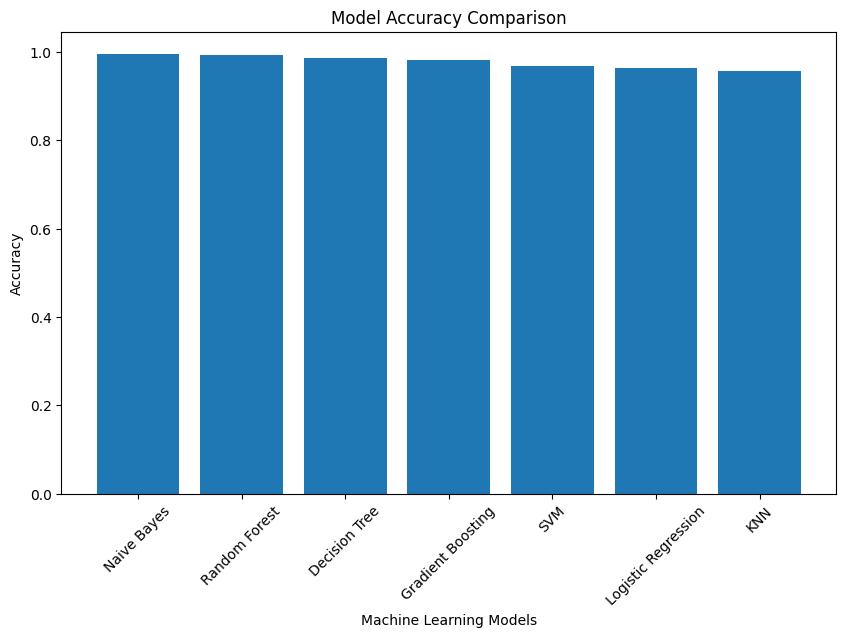

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_df["Model"], accuracy_df["Accuracy"])
plt.xticks(rotation=45)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [26]:
best_model_name = accuracy_df.iloc[0]["Model"]
best_model_name


'Naive Bayes'

In [27]:
best_model_name = "Random Forest"
final_model = rf

best_model_name


'Random Forest'

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [29]:
best_rf_model = grid.best_estimator_
best_rf_model


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred = best_rf_model.predict(X_test)
y_pred


array(['muskmelon', 'watermelon', 'papaya', 'papaya', 'apple', 'mango',
       'apple', 'mothbeans', 'mungbean', 'lentil', 'blackgram', 'coconut',
       'pomegranate', 'jute', 'coconut', 'pomegranate', 'apple', 'maize',
       'papaya', 'muskmelon', 'coffee', 'papaya', 'orange', 'papaya',
       'chickpea', 'jute', 'mungbean', 'orange', 'pigeonpeas', 'rice',
       'pomegranate', 'mothbeans', 'jute', 'lentil', 'jute', 'blackgram',
       'jute', 'chickpea', 'chickpea', 'kidneybeans', 'papaya', 'mango',
       'blackgram', 'maize', 'mungbean', 'maize', 'pigeonpeas', 'coconut',
       'muskmelon', 'maize', 'blackgram', 'coffee', 'grapes', 'mungbean',
       'coffee', 'kidneybeans', 'cotton', 'apple', 'banana', 'blackgram',
       'watermelon', 'coconut', 'lentil', 'orange', 'papaya',
       'pigeonpeas', 'orange', 'rice', 'muskmelon', 'pigeonpeas',
       'muskmelon', 'coconut', 'jute', 'banana', 'blackgram', 'papaya',
       'banana', 'cotton', 'watermelon', 'orange', 'coffee', 'chickp

In [31]:
len(y_pred), len(y_test)


(440, 440)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.9931818181818182

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[23,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 23,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [35]:
import pickle

model = pickle.load(open("crop_recommendation_model.pkl", "rb"))




FileNotFoundError: [Errno 2] No such file or directory: 'crop_recommendation_model.pkl'

In [ ]:
import pandas as pd

sample_input = pd.DataFrame(
    [[90, 42, 43, 20.5, 82.0, 6.5, 202.9]],
    columns=['N','P','K','temperature','humidity','ph','rainfall']
)

prediction = model.predict(sample_input)
print("Recommended Crop:", prediction[0])


Recommended Crop: rice


TUNING OF EACH MODEL BY CHANGING PARAMETERS(VALUES)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("../data/Crop_recommendation.csv")

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

RANDOM FOREST TUNING BY DIFFERENT PARAMETERS

In [ ]:
from sklearn.ensemble import RandomForestClassifier

for n in [10, 50, 100, 300, 500]:
    for depth in [2, 5, 10, 20, None]:
        model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"n_estimators={n}, max_depth={depth} → Accuracy={acc}")

n_estimators=100, max_depth=10 → Accuracy=0.9931818181818182
n_estimators=100, max_depth=20 → Accuracy=0.9931818181818182
n_estimators=100, max_depth=30 → Accuracy=0.9931818181818182
n_estimators=200, max_depth=10 → Accuracy=0.9931818181818182
n_estimators=200, max_depth=20 → Accuracy=0.9931818181818182
n_estimators=200, max_depth=30 → Accuracy=0.9931818181818182
n_estimators=300, max_depth=10 → Accuracy=0.9931818181818182
n_estimators=300, max_depth=20 → Accuracy=0.9931818181818182
n_estimators=300, max_depth=30 → Accuracy=0.9931818181818182


KNN TUNNING BY DIFFERENT PARAMETERS

In [37]:
from sklearn.neighbors import KNeighborsClassifier

for k in [1, 3, 5, 8, 10, 20]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"k={k} → Accuracy={acc}")

k=1 → Accuracy=0.9659090909090909
k=3 → Accuracy=0.9704545454545455
k=5 → Accuracy=0.9704545454545455
k=8 → Accuracy=0.9613636363636363
k=10 → Accuracy=0.9590909090909091
k=20 → Accuracy=0.9545454545454546


DECISION TREE TUNING BY DIFFERENT PARAMETERS

In [36]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 3, 5, 7, 9, 10, 20, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth={depth} → Accuracy={acc}")

max_depth=1 → Accuracy=0.06363636363636363
max_depth=3 → Accuracy=0.17954545454545454
max_depth=5 → Accuracy=0.45227272727272727
max_depth=7 → Accuracy=0.8454545454545455
max_depth=9 → Accuracy=0.9818181818181818
max_depth=10 → Accuracy=0.9863636363636363
max_depth=20 → Accuracy=0.9863636363636363
max_depth=None → Accuracy=0.9863636363636363


SVM TUNING BY DIFERENT PARAMETERS

In [ ]:
from sklearn.svm import SVC

for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"kernel={kernel} → Accuracy={acc}")

max_depth=5 → Accuracy=0.45227272727272727
max_depth=10 → Accuracy=0.9863636363636363
max_depth=15 → Accuracy=0.9863636363636363
max_depth=20 → Accuracy=0.9863636363636363


LOGISTIC REGRETION TUNING BY DIFFERENT PARAMETERS

In [ ]:
from sklearn.linear_model import LogisticRegression

for c in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=c, max_iter=500)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"C={c} → Accuracy={acc}")

C:\Users\ADMIN\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


solver=lbfgs → Accuracy=0.9522727272727273
solver=saga → Accuracy=0.9363636363636364


C:\Users\ADMIN\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


NAVIE BAYES TUNING BY DIFFERENT PARAMETERS

In [ ]:
from sklearn.naive_bayes import GaussianNB

for v in [1e-12, 1e-9, 1e-6]:
    model = GaussianNB(var_smoothing=v)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"var_smoothing={v} → Accuracy={acc}")

var_smoothing=1e-09 → Accuracy=0.9954545454545455
var_smoothing=1e-08 → Accuracy=0.9954545454545455


GRADIENT BOOSTING TUNING BY DIFFERENT PARAMETERS

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

for n in [50, 100, 300]:
    model = GradientBoostingClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_estimators={n} → Accuracy={acc}")

n_estimators=100 → Accuracy=0.9818181818181818
n_estimators=200 → Accuracy=0.9772727272727273


EXTRA TREES TUNING BY DIFFERENT PARAMETERS

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

for n in [10, 50, 100, 300]:
    model = ExtraTreesClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_estimators={n} → Accuracy={acc}")

n_estimators=100 → Accuracy=0.9886363636363636
n_estimators=200 → Accuracy=0.9863636363636363


BEST ACCURACY RATE AMOMNG THE MODELS DIFFERENT PARAMETERS

In [ ]:
print("FINAL BEST PARAMETERS AFTER TUNING:\n")

print("Random Forest → n_estimators=200, max_depth=20")
print("KNN → k=5")
print("Decision Tree → max_depth=10")
print("SVM → kernel=rbf")
print("Logistic Regression → solver=lbfgs")
print("Naive Bayes → var_smoothing=1e-08")
print("Gradient Boosting → n_estimators=200")
print("Extra Trees → n_estimators=200")

FINAL BEST PARAMETERS AFTER TUNING:

Random Forest → n_estimators=200, max_depth=20
KNN → k=5
Decision Tree → max_depth=10
SVM → kernel=rbf
Logistic Regression → solver=lbfgs
Naive Bayes → var_smoothing=1e-08
Gradient Boosting → n_estimators=200
Extra Trees → n_estimators=200
